# Exploratory data analysis of findings

This notebook explores the implications of these findings in cancerous tissue specimens.

## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import matplotlib.pyplot as plt
import seaborn as sns

from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

In [3]:
# noise subtype classification is applied internally by aggregate_noise_subtypes_by_cancer_type

## 1. Apply findings

Apply findings to tissue specimens that are classified as from "Total" cell population and explore.

In [4]:
from signals_in_the_noise.analysis.noise_phenotypes import aggregate_noise_subtypes_by_cancer_type
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.85, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.25, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.95, q_mod_low=None, q_mod_high=None),
)

potential_signals_norm_df = aggregate_noise_subtypes_by_cancer_type(
    list(gse.objects.values()), pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})

In [5]:
# aggregation and normalisation handled by aggregate_noise_subtypes_by_cancer_type above

In [6]:
# normalisation handled by aggregate_noise_subtypes_by_cancer_type above

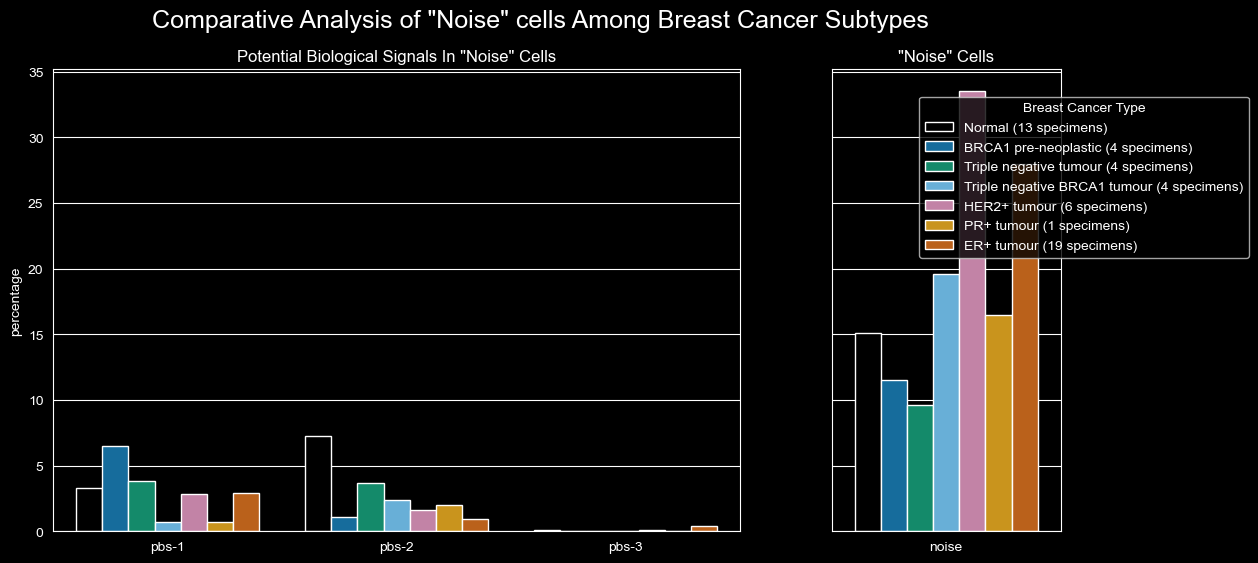

In [7]:
from signals_in_the_noise.utils.visualization import plot_noise_subtype_comparison

palette_a = [
    "#000000",  # cat 1 — black (anchor)
    "#0072B2",  # cat 2 — blue
    "#009E73",  # cat 3 — bluish green
    "#56B4E9",  # cat 4 — sky blue
    "#CC79A7",  # cat 5 — reddish purple
    "#E69F00",  # cat 6 — yellow-orange
    "#D55E00",  # cat 7 — vermillion (anchor)
]

sns.set_palette(palette_a)

ax_1, ax_2 = plot_noise_subtype_comparison(potential_signals_norm_df)

In [8]:
# real_count, noise_count

In [9]:
# noise_count/real_count

In [10]:
# -- filter data for only total cell populations and apply findings --
from collections import defaultdict
from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes

filtered_data = defaultdict(list)
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    classify_noise_subtypes(adata,pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
    })
    cancer_type = adata.uns['cancer_type']
    filtered_data[cancer_type].append(adata)

annotated_filtered_data = {}
for cancer_type, adatas in filtered_data.items():
    annotate = f"{cancer_type} ({len(adatas)} specimens)"
    annotated_filtered_data[annotate] = adatas


In [11]:
import pandas as pd 

potential_signals_by_cancer_type = {}
for cancer_type, adatas in annotated_filtered_data.items():
    sum_pbs_1 = 0
    sum_pbs_2 = 0
    sum_pbs_3 = 0
    sum_noise = 0
    sum_total = 0
    for adata in adatas:
        sum_pbs_1 += adata.obs['pbs-1'].sum()
        sum_pbs_2 += adata.obs['pbs-2'].sum()
        sum_pbs_3 += adata.obs['pbs-3'].sum()
        sum_noise += adata.obs['is_noise'].sum()
        sum_total += adata.shape[0]

    potential_signals_by_cancer_type[cancer_type] = (sum_pbs_1, sum_pbs_2, sum_pbs_3, sum_noise, sum_total)

potential_signals_df = pd.DataFrame(potential_signals_by_cancer_type)
potential_signals_df.index = ['pbs-1', 'pbs-2', 'pbs-3', 'noise', 'total']
potential_signals_df = potential_signals_df.T

In [12]:
# normalize counts to total noise (for biological signals) total count (for noise)
potential_signals_norm_df = potential_signals_df[['pbs-1', 'pbs-2', 'pbs-3']].div(potential_signals_df['noise'], axis=0)
potential_signals_norm_df['noise'] = potential_signals_df['noise'].div(potential_signals_df['total'], axis=0)
potential_signals_norm_df = potential_signals_norm_df * 100

In [13]:
# prepare data for visualization - convert to long form
long_form_potential_signals_df = potential_signals_norm_df[['pbs-1', 'pbs-2', 'pbs-3']].reset_index()
long_form_potential_signals_df.columns.values[0] = 'cancer type'
long_form_potential_signals_df = long_form_potential_signals_df.melt(
    id_vars='cancer type',
    var_name='potential signal',
    value_name='percentage of noise',
)

long_form_noise_df = potential_signals_norm_df['noise'].reset_index()
long_form_noise_df.columns.values[0] = 'cancer type'
long_form_noise_df = long_form_noise_df.melt(
    id_vars='cancer type',
    var_name='potential signal',
    value_name='percentage of noise',
)

In [14]:
cancer_types = long_form_potential_signals_df['cancer type'].unique()
idx_normal = 0
idx_pre = 1
cancer_types

array(['Normal (13 specimens)', 'BRCA1 pre-neoplastic (4 specimens)',
       'Triple negative tumour (4 specimens)',
       'Triple negative BRCA1 tumour (4 specimens)',
       'HER2+ tumour (6 specimens)', 'PR+ tumour (1 specimens)',
       'ER+ tumour (19 specimens)'], dtype=object)

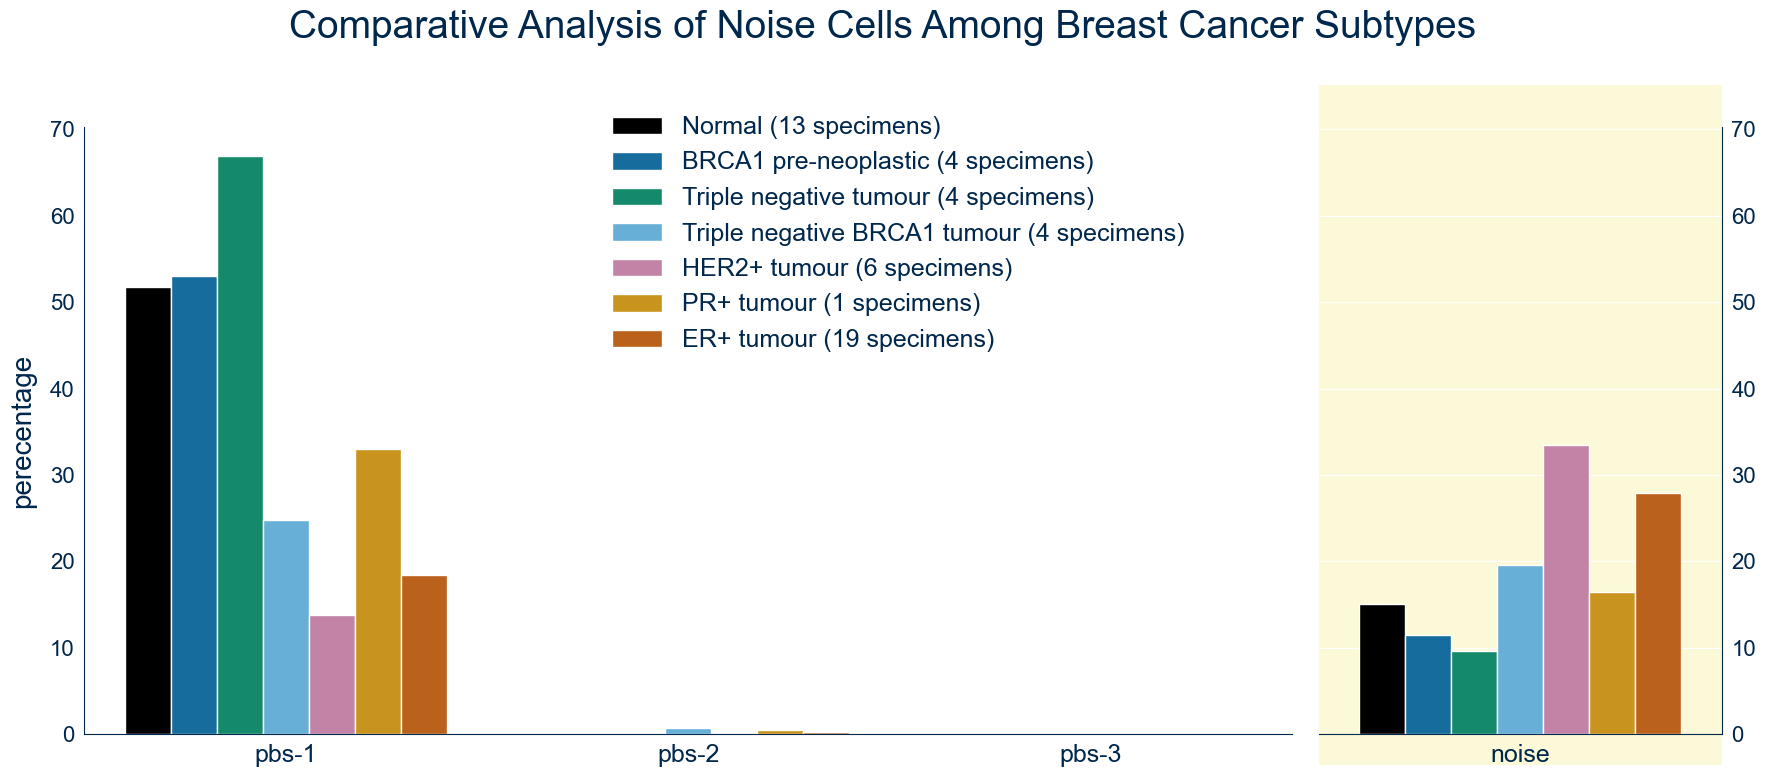

In [15]:
font_color = '#00274C'

plt.rcParams.update({
    'text.color': font_color,
    'axes.labelcolor': font_color,
    'axes.edgecolor': font_color,
    'xtick.labelcolor': font_color,
    'ytick.labelcolor': font_color,
    'font.size': 18,          # base font size
    'axes.titlesize': 24,     # subplot titles
    'axes.labelsize': 20,     # x/y labels
    'xtick.labelsize': 18,    # x tick labels
    'ytick.labelsize': 16,    # y tick labels
    'legend.title_fontsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 28    # main title
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,8), gridspec_kw={'width_ratios': [3,1]}, sharey=True)
sns.barplot(data=long_form_potential_signals_df, x='potential signal', y='percentage of noise', hue='cancer type', ax=ax1, palette=palette_a)
# ax1.set_title('Potential Biological Signals In "Noise" Cells')
ax1.set_xlabel('')
ax1.set_ylabel('perecentage', labelpad=10)
ax1.get_legend().remove()

sns.barplot(data=long_form_noise_df, x='potential signal', y='percentage of noise', hue='cancer type', ax=ax2, palette=palette_a)
# ax2.set_title('"Noise" Cells')
ax2.set_xlabel('')
ax2.set_ylabel('percentage', labelpad=10)
ax2.get_legend().remove()

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.tick_params(axis='y', which='both', right=True, labelright=True)
ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position("right")      # move label to right

import matplotlib.patches as patches
rect = patches.Rectangle(
    (0, -0.05), 1, 1.12,           # slightly extend beyond top
    transform=ax2.transAxes,
    color='#F4EE7B',
    alpha=0.3,
    zorder=-1,
    lw=0,
    clip_on=False                   # allow rectangle to spill outside
)
ax2.add_patch(rect)


handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.68, 0.7), frameon=False)
fig.patch.set_alpha(0)
for ax in fig.axes:
    ax.set_facecolor("none") 
plt.suptitle('Comparative Analysis of Noise Cells Among Breast Cancer Subtypes')
plt.tight_layout()
plt.savefig("images/umsi-expo-figure-2.png", bbox_inches='tight', dpi=300, transparent=True)

In [16]:
long_form_noise_df[long_form_noise_df['cancer type']==cancer_types[0]]

,cancer type,potential signal,percentage of noise
0,Normal (13 specimens),noise,15.066437


In [17]:
long_form_noise_df[long_form_noise_df['cancer type']==cancer_types[6]]

,cancer type,potential signal,percentage of noise
6,ER+ tumour (19 specimens),noise,27.975304


In [18]:
long_form_potential_signals_df[long_form_potential_signals_df['cancer type']==cancer_types[0]]

,cancer type,potential signal,percentage of noise
0,Normal (13 specimens),pbs-1,51.743100
7,Normal (13 specimens),pbs-2,0.197136
14,Normal (13 specimens),pbs-3,0.000000


In [19]:
long_form_potential_signals_df[long_form_potential_signals_df['cancer type']==cancer_types[6]]

,cancer type,potential signal,percentage of noise
6,ER+ tumour (19 specimens),pbs-1,18.377128
13,ER+ tumour (19 specimens),pbs-2,0.211776
20,ER+ tumour (19 specimens),pbs-3,0.000000


In [20]:
22/60

0.36666666666666664